In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch

# 1. Dynamically match PyG wheels to your Kaggle environment
torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')
cuda = f"cu{cuda_version}"
url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda}.html"

print(f"Installing PyG bindings from: {url}")

# 2. Install the Core Library
!pip install torch_geometric

# 3. Install the C++ Backend (Required for PointConv and KNN)
!pip install torch-scatter torch-sparse torch-cluster -f {url}

# 4. Install Extra Utilities
!pip install h5py seaborn scikit-learn

Installing PyG bindings from: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.4 MB/s eta 0:00:00:00:0100:01
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 100.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 91.4 MB/s eta 0:00:00:00:01


Using device: cuda
Automatically found dataset at: /kaggle/input/datasets/majdouline20/shapenetpart-dataset/PartAnnotation
Loading raw Kaggle data directly...
Successfully found 14220 train samples.
Successfully found 3555 test samples.

Started Training ContinuousSegNet (PointConv).......
Epoch 1 - Train Loss: 1.0949 | Train Acc: 53.59% || Test Loss: 1.3708 | Test Acc: 33.52%
Epoch 2 - Train Loss: 0.9393 | Train Acc: 60.25% || Test Loss: 0.8773 | Test Acc: 62.96%
Epoch 3 - Train Loss: 0.8806 | Train Acc: 63.53% || Test Loss: 1.1815 | Test Acc: 51.66%
Epoch 4 - Train Loss: 0.8458 | Train Acc: 65.47% || Test Loss: 1.3967 | Test Acc: 40.36%
Epoch 5 - Train Loss: 0.8229 | Train Acc: 66.71% || Test Loss: 1.1477 | Test Acc: 54.43%
Epoch 6 - Train Loss: 0.8035 | Train Acc: 67.65% || Test Loss: 0.9381 | Test Acc: 58.56%
Epoch 7 - Train Loss: 0.7831 | Train Acc: 68.59% || Test Loss: 0.8628 | Test Acc: 63.65%
Epoch 8 - Train Loss: 0.7744 | Train Acc: 69.05% || Test Loss: 0.8192 | Test Acc: 65.9

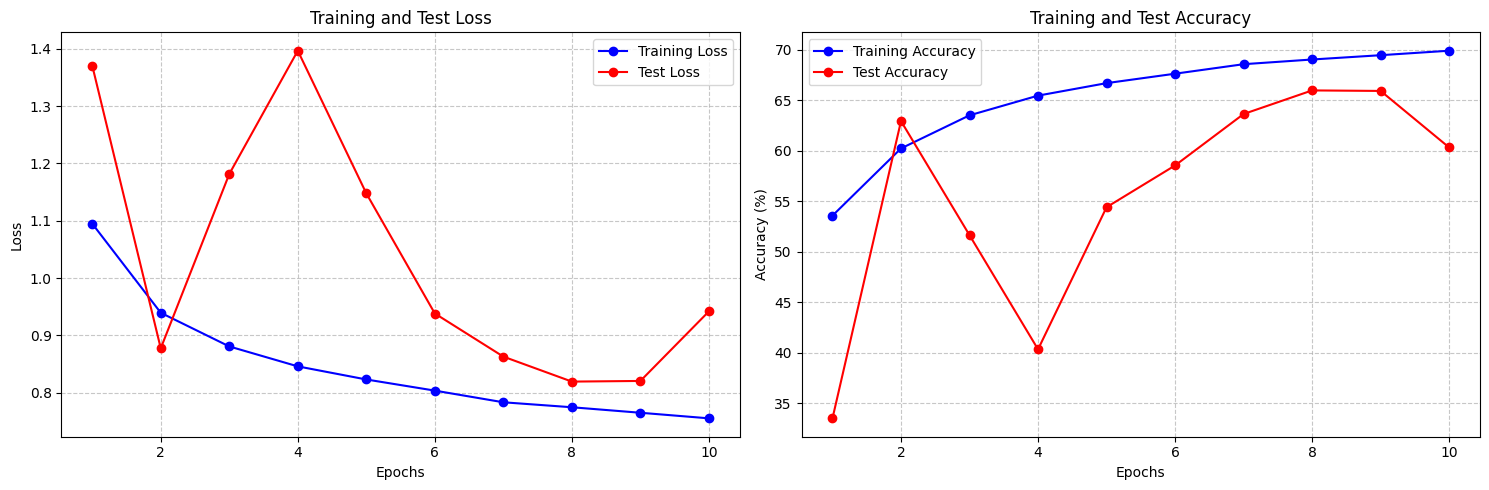


Gathering Final Metrics...

--- Plotting Class-wise F1-Scores ---


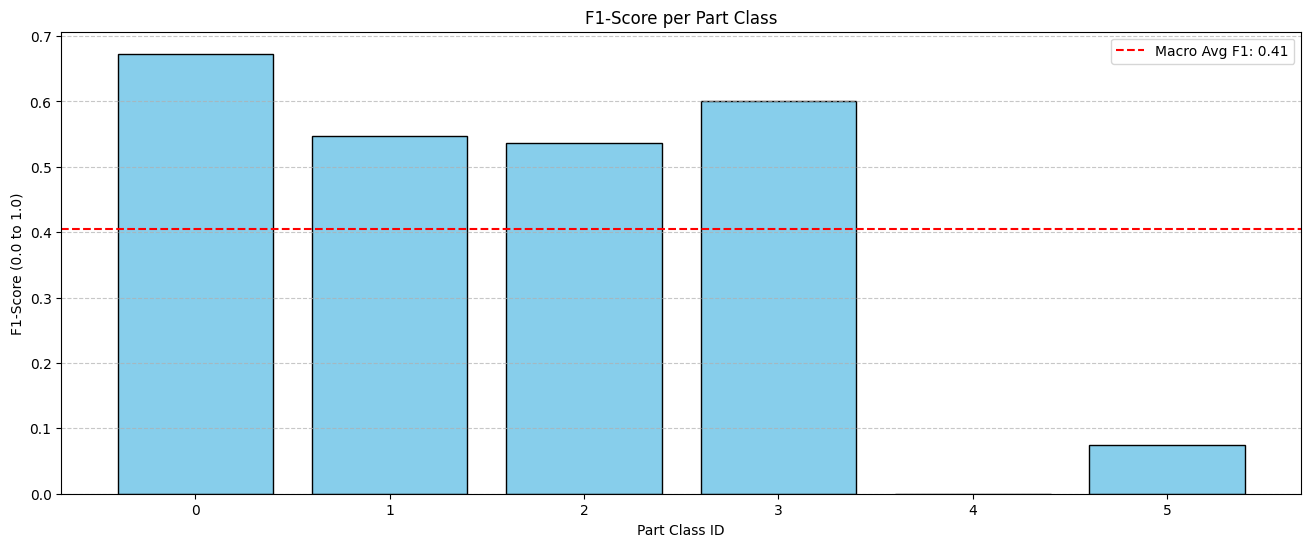


--- Plotting Normalized Confusion Matrix ---


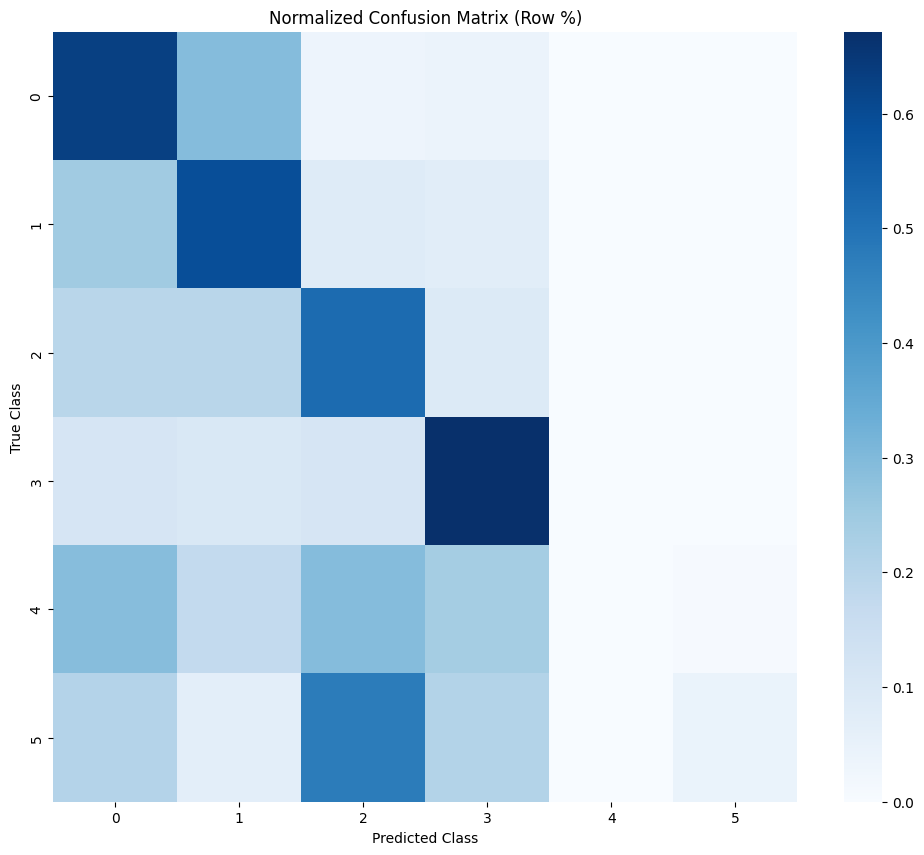


--- Visualizing Random Test Sample ---


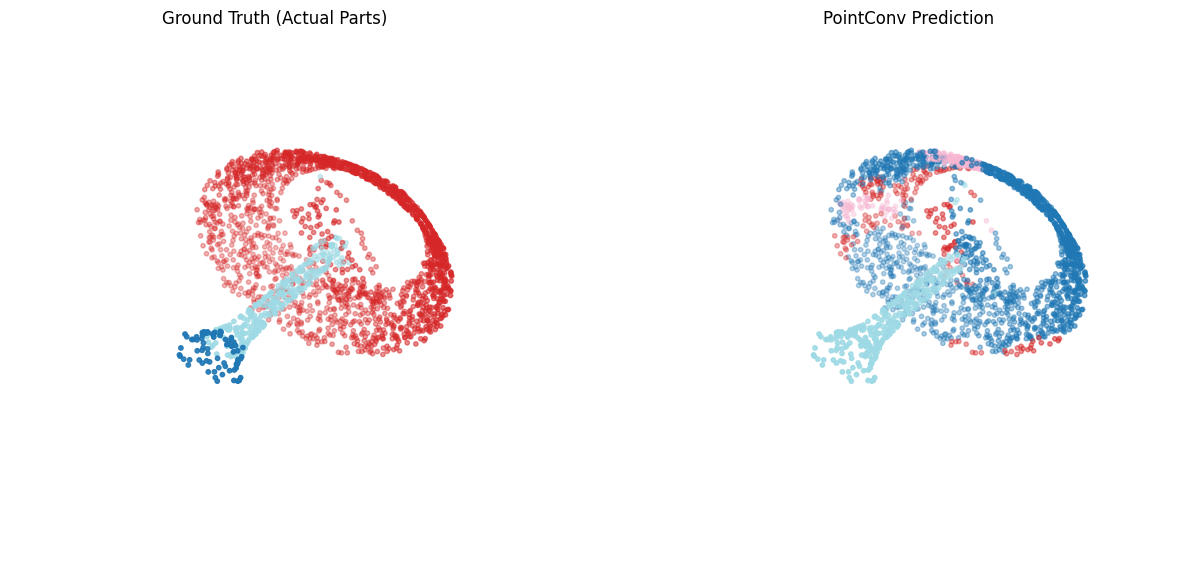

In [6]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

# --- IMPORT PyG MODULES FOR CONTINUOUS CONV ---
from torch_geometric.nn import PointNetConv, knn_graph

# ==========================================
# 1. RAW SHAPENET PART DATASET LOADER
# ==========================================
# ==========================================
# 1. RAW SHAPENET PART DATASET LOADER
# ==========================================
class RawKaggleShapeNet(Dataset):
    def __init__(self, data_dir, split='train', num_points=2048):
        self.data_dir = data_dir
        self.num_points = num_points
        self.data_pairs = []
        
        # Find all object folders (e.g., '02691156')
        synset_folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
        
        for synset in synset_folders:
            points_dir = os.path.join(data_dir, synset, 'points')
            
            if not os.path.exists(points_dir): 
                continue
                
            point_files = glob.glob(os.path.join(points_dir, '*.pts'))
            
            # Check both possible standard folder names for ShapeNet labels
            labels_dir_1 = os.path.join(data_dir, synset, 'points_label') 
            labels_dir_2 = os.path.join(data_dir, synset, 'expert_verified', 'points_label')
            
            for pts_path in point_files:
                label_filename = os.path.basename(pts_path).replace('.pts', '.seg')
                lbl_path_1 = os.path.join(labels_dir_1, label_filename)
                lbl_path_2 = os.path.join(labels_dir_2, label_filename)
                
                # Append whichever label file exists
                if os.path.exists(lbl_path_1):
                    self.data_pairs.append((pts_path, lbl_path_1))
                elif os.path.exists(lbl_path_2):
                    self.data_pairs.append((pts_path, lbl_path_2))
                    
        if len(self.data_pairs) == 0:
            raise ValueError(f"Found 0 files! Scanned directory: {data_dir}")
            
        # Create Train/Test split
        np.random.seed(42) 
        np.random.shuffle(self.data_pairs)
        split_idx = int(len(self.data_pairs) * 0.8)
        
        if split == 'train':
            self.data_pairs = self.data_pairs[:split_idx]
        else:
            self.data_pairs = self.data_pairs[split_idx:]
            
        print(f"Successfully found {len(self.data_pairs)} {split} samples.")

    def __len__(self):
        return len(self.data_pairs)

    def __getitem__(self, idx):
        pts_path, lbl_path = self.data_pairs[idx]
        
        # Load raw text data
        points = np.loadtxt(pts_path).astype(np.float32)
        labels = np.loadtxt(lbl_path).astype(np.int64) 
        
        # Shift labels to start at 0
        if labels.min() > 0:
            labels = labels - labels.min()

        # Sample exactly num_points (e.g. 2048) so batches work
        if len(points) >= self.num_points:
            choice = np.random.choice(len(points), self.num_points, replace=False)
        else:
            choice = np.random.choice(len(points), self.num_points, replace=True)
            
        points = points[choice, :]
        labels = labels[choice]

        # Normalization (Center and Scale)
        points = points - np.mean(points, axis=0)
        dist = np.max(np.sqrt(np.sum(points ** 2, axis=1)), 0)
        points = points / (dist + 1e-8)

        return torch.from_numpy(points), torch.from_numpy(labels)
# ==========================================
# 2. CONTINUOUS POINTCONV ARCHITECTURE
# ==========================================
class ContinuousSegNet(nn.Module):
    def __init__(self, num_classes=50):
        super(ContinuousSegNet, self).__init__()
        
        self.conv1 = PointNetConv(local_nn=nn.Sequential(
            nn.Linear(3, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, 64)
        ), aggr='add')
        
        self.conv2 = PointNetConv(local_nn=nn.Sequential(
            nn.Linear(64 + 3, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Linear(128, 128)
        ), aggr='add')
        
        self.conv3 = PointNetConv(local_nn=nn.Sequential(
            nn.Linear(128 + 3, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Linear(256, 256)
        ), aggr='add')
        
        self.lin1 = nn.Linear(256, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.lin2 = nn.Linear(128, num_classes)

    def forward(self, xyz):
        B, N, _ = xyz.shape
        device = xyz.device
        
        # Bridge: Flatten batch for PyG
        pos = xyz.view(B * N, 3) 
        batch = torch.arange(B, device=device).repeat_interleave(N)
        
        edge_index1 = knn_graph(pos, k=16, batch=batch)
        x1 = F.relu(self.conv1(x=None, pos=pos, edge_index=edge_index1))
        
        edge_index2 = knn_graph(pos, k=16, batch=batch)
        x2 = F.relu(self.conv2(x=x1, pos=pos, edge_index=edge_index2))
        
        edge_index3 = knn_graph(pos, k=16, batch=batch)
        x3 = F.relu(self.conv3(x=x2, pos=pos, edge_index=edge_index3))
        
        x = F.relu(self.bn1(self.lin1(x3)))
        x = self.drop1(x)
        x = self.lin2(x) 
        
        x = x.view(B, N, -1).permute(0, 2, 1) 
        return F.log_softmax(x, dim=1)

# ==========================================
# 3. VISUALIZERS & PLOTTING UTILS
# ==========================================
def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'ro-', label='Test Loss')
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, history['train_acc'], 'bo-', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], 'ro-', label='Test Accuracy')
    ax2.set_title('Training and Test Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_class_f1_scores(targets, preds):
    report = classification_report(targets, preds, output_dict=True, zero_division=0)
    classes, f1_scores = [], []
    for key, value in report.items():
        if key.isdigit():
            classes.append(int(key))
            f1_scores.append(value['f1-score'])
            
    plt.figure(figsize=(16, 6))
    plt.bar(classes, f1_scores, color='skyblue', edgecolor='black')
    
    macro_f1 = report['macro avg']['f1-score']
    plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro Avg F1: {macro_f1:.2f}')
    
    plt.title('F1-Score per Part Class')
    plt.xlabel('Part Class ID')
    plt.ylabel('F1-Score (0.0 to 1.0)')
    plt.xticks(classes) 
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def visualize_random_prediction(model, dataset, device):
    model.eval()
    idx = random.randint(0, len(dataset) - 1)
    points, target = dataset[idx]
    
    points_batch = points.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(points_batch)
        pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
        
    points_np = points.numpy()
    target_np = target.numpy()
    
    fig = plt.figure(figsize=(15, 7))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], c=target_np, cmap='tab20', s=10)
    ax1.set_title("Ground Truth (Actual Parts)")
    ax1.axis('off')
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], c=pred, cmap='tab20', s=10)
    ax2.set_title("PointConv Prediction")
    ax2.axis('off')
    
    plt.show()

# ==========================================
# 4. TRAINING & EVALUATION PIPELINE
# ==========================================
def run_segmentation():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # --- AUTO-FIND THE DATASET PATH ---
    KAGGLE_INPUT_DIR = None
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'PartAnnotation' in dirs:
            KAGGLE_INPUT_DIR = os.path.join(root, 'PartAnnotation')
            break
            
    if KAGGLE_INPUT_DIR is None:
        print("ERROR: Could not find PartAnnotation directory in /kaggle/input/")
        return
        
    print(f"Automatically found dataset at: {KAGGLE_INPUT_DIR}")
    print("Loading raw Kaggle data directly...")
    
    train_ds = RawKaggleShapeNet(data_dir=KAGGLE_INPUT_DIR, split='train')
    test_ds = RawKaggleShapeNet(data_dir=KAGGLE_INPUT_DIR, split='test')
    
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, drop_last=False)

    model = ContinuousSegNet(num_classes=50).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.NLLLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("\nStarted Training ContinuousSegNet (PointConv).......")
    for epoch in range(10):
        # --- TRAINING ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for points, target in train_loader:
            points, target = points.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(points)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_correct += (output.argmax(dim=1) == target).sum().item()
            train_total += target.numel() 

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # --- TESTING ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for points, target in test_loader:
                points, target = points.to(device), target.to(device)
                output = model(points)
                loss = criterion(output, target)
                val_loss += loss.item()
                val_correct += (output.argmax(dim=1) == target).sum().item()
                val_total += target.numel()

        avg_val_loss = val_loss / len(test_loader)
        val_acc = 100. * val_correct / val_total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% || Test Loss: {avg_val_loss:.4f} | Test Acc: {val_acc:.2f}%")

    # Save Model
    save_path = "pointconv_partseg_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel weights saved to: {save_path}")

    print("\n--- Plotting Learning Curves ---")
    plot_learning_curves(history)

    # --- FINAL TEST EVALUATION ---
    print("\n==========================================")
    print("Gathering Final Metrics...")
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for points, target in test_loader:
            points, target = points.to(device), target.to(device)
            output = model(points)
            preds = output.argmax(dim=1)
            
            all_preds.append(preds.view(-1).cpu().numpy())
            all_targets.append(target.view(-1).cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    print("\n--- Plotting Class-wise F1-Scores ---")
    plot_class_f1_scores(all_targets, all_preds)

    print("\n--- Plotting Normalized Confusion Matrix ---")
    cm = confusion_matrix(all_targets, all_preds, normalize='true') 
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', fmt='.2f')
    plt.title('Normalized Confusion Matrix (Row %)')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    print("\n--- Visualizing Random Test Sample ---")
    visualize_random_prediction(model, test_ds, device)

    return model

# Run it!
if __name__ == "__main__":
    model = run_segmentation()